# Анализ результатов RuBERT frozen encoder

Этот ноутбук показывает результаты эксперимента с `DeepPavlov/rubert-base-cased`: encoder был заморожен, а сверху обучалась multi-label классификационная голова.

В ноутбуке выводятся только основные результаты: summary-метрики, динамика обучения, thresholds и качество по классам.


## 1. Загружаем результаты эксперимента

Здесь загружаются CSV-файлы с результатами RuBERT frozen encoder: summary-метрики, per-class метрики, история обучения и подобранные пороги по классам.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import base64, gzip, io
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

_DATA = {"summary_metrics_rubert_frozen_encoder": "H4sIAOMvNGoC/32Qy2rDMBBF9/mWUDTvmW2hPxC6FyZRaoNjFyd90K+vFEwIhVQb6V7umYfK93tZhlOZLttTt1/m/L6U/XAe5mnVVXbjuIojbE/Dn9RwnxrW1FcZ3vpLOdwFb9aavekjbHYfzy+713xc5p8y5b50h5wv/VLO/TwecsqyTU8srsnZk4aDm1XLRCQhepiSptRSoiDsBErRXtBAtcpVg8OZUBtIiQJB1BWNBa5gmIcahyCERwPNKaC1SNUOfwiSkpt7MqzX/8vUfecpf3ZjIyGhEUUd0wmpFbMEbAldqg2qeq3PSGiOFqKYuA0WyjVk1mZmaF+hphUUdyTBYGygoQJDqpORg/G1o4jWFkzKHIgPwHqo7sRmxkls8wuF+CarJQIAAA==", "per_class_metrics_rubert_frozen_encoder": "H4sIAOMvNGoC/6WWzW4TMRDH7zxFHmAF/pgZ21ckXgBxX0XtQiuFpEpShDi1ILUHKvXCFXHjHAqh3+0reN+IGacp68CWkOwqljPetL/5+++Zrd7uVMPt11V/XGz0uqNRsTOsNrZH24N+wZNur1e81MVod2dnMBwX4+FuVQ6746p8NehtVn15eHN7Y1xtNqOPnu8+ffb8RflyOHhX9cutqrtZluOtYTXa4vVSlVjET/Ve/SF+j5P6uBNv6714E7/FyziNV3FSqMd24eKQ5w84hd4biyaA1o4K5KCyoLQlhQCGY/Kc8pqsIbSKtDEAyxB9jtN6nzFu6vfxhOfv6/00O4vTTrxg0D3+elMf8nzakSmvcTDhwp+4oMgIHehgEbz1TgVyDgprOJpAnXLgTQhWBwkpyLCXYf7CFJf8+RnPmGgaL+ujeF1/jOedJ514zYFzToMRGwspv1OenojMQIHJHKJW/P+1yKwCGvt7lBQ8Og3mfiyMPNiMyPiXXVsqhXzvO/EHE4ryE9b3Ip5JJreSZv2BtZ9yVmf1sUCBs+R5xxUaspo4FCC/OEQqI9eFFs7kCR9cwKC9JSfqo8emkVZBr/c7zHwTT+OJiJ48csV/Gz0ZRT4Qy+xMm8ps3DZddXDG+aA1ErCr/Kpw4uJDsXkyNsMt+vgO0Dr2JKshWA5Ae1JAqDUZJ04la6nxcQWI4U0w/GvFiSrjjJZUbABEx+dVzxZX52ZWdoHELsQa9YEcy2RzriK37JWLlIeM52IOoVy4JL3CyEpeG3w6fEysvAeL1oHGFUHTUTvlb9O0dnXnXS4rE7b1HC5ZVVsFFlgbUp6ChJrCc1lgN4iq8y2fm1NYbeaeZVi/poMzEbkO0vR6dsjqIxEr91va9LzMSggXS5yWY6MX+JJZFTj6PT7Mx51j0C/fdHv/bgmU33ctAVt7wH1xnR2epTnWaQTCor3DmaWyu7Xw/1+zaoCuW/0x7euCndJWE2/o/UDtdamhOOeEy5OvWvQxv8UDuS0h1duGd+Ghop9H7Mr8bZWfN9UD6fkY/l75nWH3gkFkP2gI7XLn1nFr4f6zF9wXJyTkHRZhHWXdwCatQ5PTtvaC/E1D+TXh/7Mh2HQkZwcTTXsfsAvbsw7lkt1AZXd6OZhrbmdtQpTP7WDbm8Oqln6wRZDOLilklL+Liz8pdyy1t4gFyke/APyGwtuFDAAA", "rubert_frozen_encoder_thresholds": "H4sIAOMvNGoC/3VTS24bMQzd+xRzgEGrHynpNIWRpkgAozbstGs7AZJFA2TTbZFd167bqf/2FagbhWTqJlO7woyGojR8j+TTWa87GtVXF8Pz0UW/977+3O29GwzPzy5Hl/2PuuJFt9dT84PVz+jTYNAfXnXoaxmXG/pJ0/JQ0b6MaUc/aE0NbWhamzdgcmuwK/gI/IntkeQw1jZ16Bs1ZcJxduWaZmxfl4laC2oqWjHSmJe7csd2U4nJe+xUPMRjPHmjgZScB5eDtRGVhms9tQ8deuRga35/04IDN7Qu97QtX2hZva1oy44ls2GkVxtKc87mTODjETxEG1x6meWUtxBTDtFjCs6Kp/ac+GO7fBX94uCS+5QzXNFCSOyFYbnh7BsmtCgPAqE4NrUeKfFzfANOEeUUmoQZEJyNPltvT+KWScWAO5rTTJLVEm8Ewh9nFxCsRRezwRwxCmpGtMZiDtmCA004JBchoTOYMgLUkE+jSnfvpP3acEb9t78Bjik4k/zLCKotsNnHnELIaJ1ScJ7rkCGDsQCsAOv+y4Fxuc7iW0nxy61ITzXAUt9zN1bKSealcLLHmrP4emhZsC3C53ryvyZF6zGzs05wkpIqbs6rRvc2f3TAl2TKEjnQgBM0Isf15u+smkgmgzvMSiPm4LPjpccQEtbBdei76msqOd+quX3WYrlXAR9BcbtbQ6EO100zV/T2XfBy6Z4AmOT8j38EAAA=", "training_history": "H4sIAOMvNGoC/y1UWWpbQRD877MI0/tymocwCQk4cbBNzp/qeUEfEqOaXmqZb3/eX388vj6eP39fb++fn4+/z7fr1/P14/36Ltfz6+IrSB7ywhUzzDFmwtYPfsGPdNXAd7B4k+Jw2r3c2mzE3PbIsqx5jBeU4mSLM3G2nFDPLseJ40Aqh70jzIf2sKdHmt1mxt1ny/XkVLFWabcaxeIyJTKsKypaF+eBo9EIDy/JpFzcDpxbrjg7dhJP1JrEZts2gmpx6j2M2dKw9P/xsJlKW8qYJi0FzVbpXF421bY3gWFtrWbMZmi7s9QwrpQorrqWLG4KhYJ50LdKSHiBVeGDc3OAa0fGIF0yLtwYh4dkrxcGi1KAGWr06TwtM+lSpuBBSZb9CikwyOjnqXaYAUEDuni2uaH18oC/RXZLSJychxpM0lhPy8F/OckyUasthFORHqh3gG6hO3XVgDuSFQVsYT8rKMfRvRWDVRPThHTsXZJdsSRgDYZYyhbHDcEFL6ShvRgsQbIrFuqA/7QEm3Vah6iDU9wSqD9J0ge4qjPUxjRxA1mToRZ2YbgK9CwX6DEAjYKKjkNtMD7YAyPAJTGkq0zCuhDEwrs7XO/WvRVxEXRLksoBchnMBZ/C8vfW0F07eBChViXd21k4cLQMgWP1XnrNDvGQIDQWUjtAkRwfC4sIvWl0BQk2ndC8UHGvIwPwaG/8ttDtstFcwjAi8oZdVpiMo7yALpSxexdsDQXFFXYGO5oHmCw7E+tG5rADRjEEKiKAEkW6wiTaKmQYvBLIcx4gFLKWhgyVGaR9gO4ynODH4KubHW5kF7bbxJbRie/6OwFASkHJLQyIArPRSIzgnSE7wjhiqrPJVsbTdIDwY7LBdwMzB9kRRjdptmqhRtzLqAnSo15ImQsdLgAUbI3XBSJw+l3RlnIWzIN0kB1lFHnBi4W1Qe6JP6SGXUOXBAwq9A9JbccZYQUAAA=="}

def _load_csv(name):
    raw = gzip.decompress(base64.b64decode(_DATA[name]))
    return pd.read_csv(io.BytesIO(raw))

dfs = {name: _load_csv(name) for name in _DATA}

def fmt(df, digits=3):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out

tables_info = pd.DataFrame([
    {"table": name, "rows": df.shape[0], "columns": df.shape[1]}
    for name, df in dfs.items()
]).sort_values("table")

display(tables_info)

,table,rows,columns
1,per_class_metrics_rubert_frozen_encoder,18,8
2,rubert_frozen_encoder_thresholds,9,6
0,summary_metrics_rubert_frozen_encoder,2,10
3,training_history,33,3


## 2. Summary-метрики: стандартный threshold 0.5 vs подобранные thresholds

Threshold tuning немного улучшил `macro_f1`: с `0.562` до `0.564`.

Но улучшение очень маленькое. Основной эффект — precision выросла, а recall снизился. То есть модель стала чуть аккуратнее, но начала пропускать больше настоящих классов.

Итог: подбор порогов помогает слабо, потому что основное ограничение здесь не в threshold, а в качестве признаков/обучения frozen encoder.

In [ ]:
summary = dfs["summary_metrics_rubert_frozen_encoder"].copy()
display(fmt(summary))

,experiment,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,weighted_precision,weighted_recall,weighted_f1
0,RuBERT_frozen_head__threshold_0_5,0.459,0.756,0.562,0.467,0.730,0.570,0.478,0.730,0.569
1,RuBERT_frozen_head__thresholded_on_val,0.510,0.701,0.564,0.496,0.676,0.573,0.516,0.676,0.556


## 3. Динамика обучения

Train loss устойчиво снижается, значит классификационная голова действительно обучается.

Лучшее значение `val_macro_f1_at_0_5` достигается на 26-й эпохе: примерно `0.528`.  
После этого сильного роста уже нет, качество колеблется около одного уровня. Это говорит о том, что модель быстро упирается в потолок качества при замороженном RuBERT encoder.

,best_epoch,best_val_macro_f1_at_0_5,first_train_loss,last_train_loss,loss_delta
0,26,0.528,1.076,0.624,-0.452


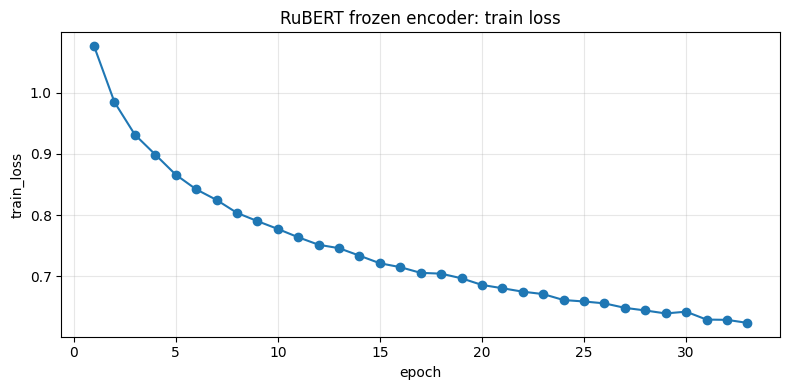

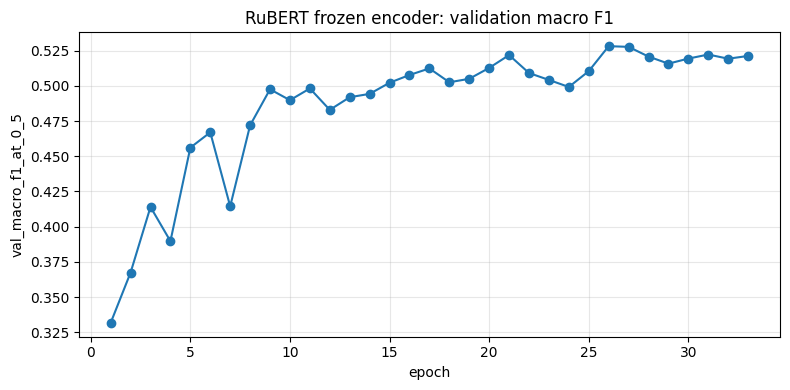

In [ ]:
history = dfs["training_history"].copy()
best_epoch = history.loc[history["val_macro_f1_at_0_5"].idxmax()]

display(fmt(pd.DataFrame([{
    "best_epoch": int(best_epoch["epoch"]),
    "best_val_macro_f1_at_0_5": best_epoch["val_macro_f1_at_0_5"],
    "first_train_loss": history["train_loss"].iloc[0],
    "last_train_loss": history["train_loss"].iloc[-1],
    "loss_delta": history["train_loss"].iloc[-1] - history["train_loss"].iloc[0],
}])))

plt.figure(figsize=(8, 4))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="train_loss")
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("RuBERT frozen encoder: train loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["epoch"], history["val_macro_f1_at_0_5"], marker="o", label="val_macro_f1_at_0_5")
plt.xlabel("epoch")
plt.ylabel("val_macro_f1_at_0_5")
plt.title("RuBERT frozen encoder: validation macro F1")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Подобранные thresholds по классам

Пороги лежат примерно в диапазоне `0.42–0.68`.

Самые высокие пороги у:
- `Положительный / нейтральный отзыв`;
- `Несоответствие карточке товара`;
- `Цена / ценность`.

Самые низкие пороги у:
- `Проблема с комплектацией / упаковкой`;
- `Проблема с качеством товара`.

Это показывает, что модель по-разному калибрована по классам: для одних классов нужны более строгие пороги, для других — более мягкие.

In [ ]:
thresholds = dfs["rubert_frozen_encoder_thresholds"].copy()
display(fmt(thresholds.sort_values("threshold", ascending=False)))

,class,threshold,val_precision,val_recall,val_f1,val_support
2,Положительный / нейтральный отзыв,0.68,0.571,0.632,0.600,38
1,Несоответствие карточке товара,0.67,0.400,0.471,0.432,34
8,Цена / ценность,0.64,0.694,0.735,0.714,34
3,Проблема доставки / получения,0.59,0.519,0.737,0.609,38
4,Проблема с возвратом,0.54,0.547,0.797,0.648,59
7,Проблема с размером / посадкой,0.52,0.477,0.738,0.579,42
0,Другая проблема,0.51,0.438,0.778,0.560,18
5,Проблема с качеством товара,0.46,0.521,0.775,0.623,129
6,Проблема с комплектацией / упаковкой,0.42,0.417,0.765,0.539,85


## 5. Качество по классам

Лучшая версия по summary-метрикам — `RuBERT_frozen_head__thresholded_on_val`.

Сильнее всего модель справляется с:
- `Проблема с возвратом`;
- `Проблема с размером / посадкой`;
- `Цена / ценность`.

Слабее всего:
- `Несоответствие карточке товара`;
- `Другая проблема`.

Особенно заметная проблема — `Несоответствие карточке товара`: после подбора threshold recall резко падает, и итоговый F1 становится низким.

In [ ]:
per_class = dfs["per_class_metrics_rubert_frozen_encoder"].copy()
best_experiment = summary.sort_values("macro_f1", ascending=False).iloc[0]["experiment"]

best_pc = per_class[per_class["experiment"] == best_experiment].copy()
best_pc_view = best_pc[[
    "class", "precision", "recall", "f1", "support",
    "true_rate_golden", "predicted_rate_golden"
]].sort_values("f1", ascending=False)

display(fmt(best_pc_view))

,class,precision,recall,f1,support,true_rate_golden,predicted_rate_golden
13,Проблема с возвратом,0.654,0.810,0.723,21,0.143,0.177
16,Проблема с размером / посадкой,0.606,0.870,0.714,23,0.156,0.224
17,Цена / ценность,0.611,0.647,0.629,17,0.116,0.122
14,Проблема с качеством товара,0.478,0.767,0.589,43,0.293,0.469
12,Проблема доставки / получения,0.455,0.833,0.588,18,0.122,0.224
11,Положительный / нейтральный отзыв,0.550,0.524,0.537,21,0.143,0.136
15,Проблема с комплектацией / упаковкой,0.375,0.875,0.525,24,0.163,0.381
9,Другая проблема,0.364,0.800,0.500,5,0.034,0.075
10,Несоответствие карточке товара,0.500,0.188,0.273,32,0.218,0.082


## 6. График per-class F1 для лучшей версии RuBERT

График подтверждает, что качество по классам неоднородное.  
Модель неплохо видит несколько конкретных классов, но хуже справляется с более смысловыми и широкими категориями.

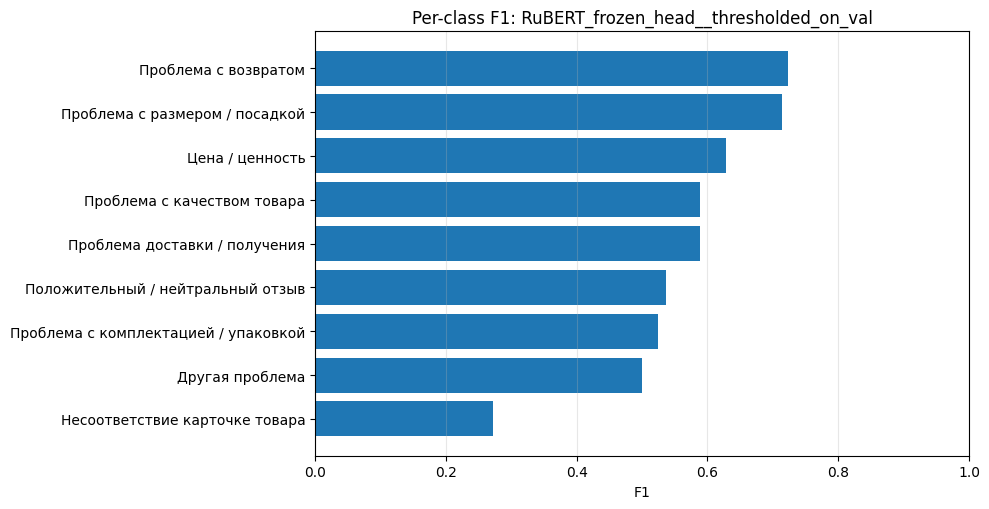

In [ ]:
plot_pc = best_pc_view.sort_values("f1", ascending=True)

plt.figure(figsize=(10, 5.2))
plt.barh(plot_pc["class"], plot_pc["f1"])
plt.xlabel("F1")
plt.title(f"Per-class F1: {best_experiment}")
plt.xlim(0, 1.0)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Как threshold tuning изменил per-class качество

Threshold tuning дал смешанный эффект.

Улучшились:
- `Цена / ценность`;
- `Положительный / нейтральный отзыв`;
- `Проблема с возвратом`.

Сильно ухудшился класс:
- `Несоответствие карточке товара`.

Итог: threshold tuning немного улучшает общую macro F1, но не решает главную проблему качества модели.

In [ ]:
base = per_class[per_class["experiment"] == "RuBERT_frozen_head__threshold_0_5"].set_index("class")
thr = per_class[per_class["experiment"] == "RuBERT_frozen_head__thresholded_on_val"].set_index("class")

delta = base[["precision", "recall", "f1", "predicted_rate_golden"]].join(
    thr[["precision", "recall", "f1", "predicted_rate_golden"]],
    lsuffix="_0_5",
    rsuffix="_thresholded"
)

delta["delta_f1"] = delta["f1_thresholded"] - delta["f1_0_5"]
delta["delta_precision"] = delta["precision_thresholded"] - delta["precision_0_5"]
delta["delta_recall"] = delta["recall_thresholded"] - delta["recall_0_5"]

delta_view = delta.reset_index()[[
    "class",
    "f1_0_5",
    "f1_thresholded",
    "delta_f1",
    "precision_0_5",
    "precision_thresholded",
    "recall_0_5",
    "recall_thresholded"
]].sort_values("delta_f1", ascending=False)

display(fmt(delta_view))

,class,f1_0_5,f1_thresholded,delta_f1,precision_0_5,precision_thresholded,recall_0_5,recall_thresholded
8,Цена / ценность,0.533,0.629,0.095,0.429,0.611,0.706,0.647
2,Положительный / нейтральный отзыв,0.486,0.537,0.051,0.347,0.550,0.810,0.524
4,Проблема с возвратом,0.680,0.723,0.043,0.586,0.654,0.810,0.810
0,Другая проблема,0.471,0.500,0.029,0.333,0.364,0.800,0.800
6,Проблема с комплектацией / упаковкой,0.500,0.525,0.025,0.400,0.375,0.667,0.875
7,Проблема с размером / посадкой,0.724,0.714,-0.010,0.600,0.606,0.913,0.870
3,Проблема доставки / получения,0.607,0.588,-0.019,0.447,0.455,0.944,0.833
5,Проблема с качеством товара,0.634,0.589,-0.044,0.552,0.478,0.744,0.767
1,Несоответствие карточке товара,0.419,0.273,-0.147,0.433,0.500,0.406,0.188


## 8. Итоговый вывод по RuBERT frozen encoder

RuBERT frozen encoder работает как baseline, но сильно уступает embedding-подходу.

Главная причина: encoder был заморожен, поэтому модель обучала только верхнюю классификационную голову. Для маленького и шумного multi-label датасета этого оказалось недостаточно.

Практический вывод: эту модель можно оставить как нейросетевой baseline, но для финального решения лучше использовать embedding-модель `bge-m3` + линейный классификатор или пробовать полноценный fine-tuning RuBERT.

In [ ]:
rub_best = summary.sort_values("macro_f1", ascending=False).iloc[0]

final_summary = pd.DataFrame([{
    "best_rubert_version": rub_best["experiment"],
    "macro_precision": rub_best["macro_precision"],
    "macro_recall": rub_best["macro_recall"],
    "macro_f1": rub_best["macro_f1"],
    "micro_f1": rub_best["micro_f1"],
    "weighted_f1": rub_best["weighted_f1"],
    "main_conclusion": "baseline, но качество заметно ниже embedding-подхода"
}])

display(fmt(final_summary))

,best_rubert_version,macro_precision,macro_recall,macro_f1,micro_f1,weighted_f1,main_conclusion
0,RuBERT_frozen_head__thresholded_on_val,0.51,0.701,0.564,0.573,0.556,"baseline, но качество заметно ниже embedding-подхода"
